In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
lot_area = df['LotArea']

In [23]:
def detect_outliers_iqr(data):
    sorted_data = np.sort(data)
    Q1 = np.percentile(sorted_data, 25)
    Q3 = np.percentile(sorted_data, 75)
    IQR = Q3 - Q1
    Tlower = Q1 - (1.5 * IQR)
    Tupper = Q3 + (1.5 * IQR)

    outliers = data[(data < Tlower) | (data > Tupper)]
    
    return Q1, Q3, IQR, Tlower, Tupper, outliers

Original dataset size: 1460
Number of outliers removed: 69
Preprocessed dataset size: 1391


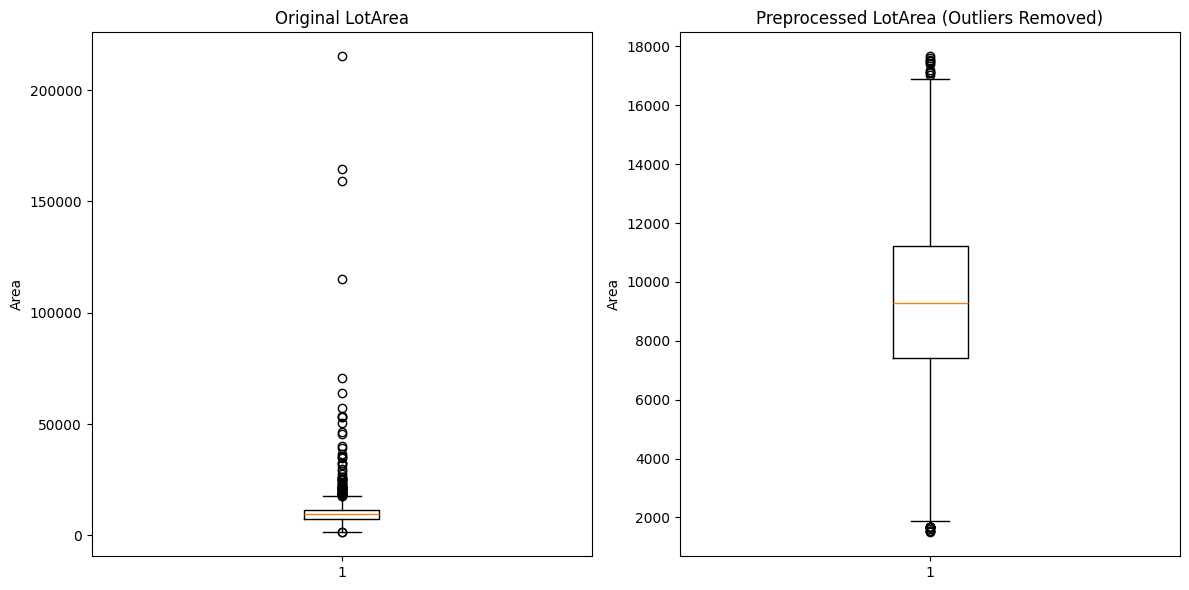

In [24]:
# iqr params
Q1, Q3, IQR, Tlower, Tupper, outliers = detect_outliers_iqr(lot_area)

# cleaned
lot_area_cleaned = lot_area[(lot_area >= Tlower) & (lot_area <= Tupper)]

print(f"Original dataset size: {len(lot_area)}")
print(f"Number of outliers removed: {len(outliers)}")
print(f"Preprocessed dataset size: {len(lot_area_cleaned)}")

# comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.boxplot(lot_area)
plt.title('Original LotArea')
plt.ylabel('Area')

plt.subplot(1, 2, 2)
plt.boxplot(lot_area_cleaned)
plt.title('Preprocessed LotArea (Outliers Removed)')
plt.ylabel('Area')

plt.tight_layout()
plt.show()